# MMLU Benchmark Evaluation
Testing the adaptive learning model on MMLU (Massive Multitask Language Understanding)

**Why MMLU:**
- Widely recognized benchmark
- Has actual question text (unlike EEDI)
- Covers math, science, reasoning - our training domains
- Unseen data - true test of generalization

**Metrics:** Accuracy, F1 Score

## 1. Setup and Load MMLU

In [1]:
!pip install -q datasets transformers accelerate peft bitsandbytes torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.9 MB/s eta 0:00:00


In [2]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from tqdm import tqdm
import json

print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

CUDA: True
GPU: Tesla T4


In [3]:
# Load MMLU dataset
print("Loading MMLU dataset...\n")

# We'll focus on relevant subjects
subjects = [
    "elementary_mathematics",
    "high_school_mathematics",
    "high_school_physics",
    "high_school_chemistry",
    "high_school_biology",
    "logical_fallacies",
]

mmlu_data = {}
for subject in subjects:
    try:
        dataset = load_dataset("cais/mmlu", subject, split="test")
        mmlu_data[subject] = dataset
        print(f"✓ {subject}: {len(dataset)} questions")
    except Exception as e:
        print(f"✗ {subject}: Failed to load - {e}")

print(f"\nTotal subjects loaded: {len(mmlu_data)}")

Loading MMLU dataset...



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

elementary_mathematics/test-00000-of-000(…):   0%|          | 0.00/41.1k [00:00<?, ?B/s]

...

logical_fallacies/dev-00000-of-00001.par(…):   0%|          | 0.00/4.12k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/163 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/18 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/5 [00:00<?, ? examples/s]

✓ logical_fallacies: 163 questions

Total subjects loaded: 6


In [4]:
# Explore MMLU format
sample_subject = list(mmlu_data.keys())[0]
sample = mmlu_data[sample_subject][0]

print(f"Sample from {sample_subject}:")
print(f"Keys: {sample.keys()}")
print(f"\nQuestion: {sample['question']}")
print(f"Choices: {sample['choices']}")
print(f"Answer: {sample['answer']} (index of correct choice)")

Sample from elementary_mathematics:
Keys: dict_keys(['question', 'subject', 'choices', 'answer'])

Question: What is the value of p in 24 = 2p?
Choices: ['p = 4', 'p = 8', 'p = 12', 'p = 24']
Answer: 2 (index of correct choice)


## 2. Load Fine-tuned Model

In [5]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load model
base_model_name = "mistralai/Mistral-7B-v0.1"
model_path = "/content/drive/MyDrive/adaptive-learning-evaluation-FINAL"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(base_model_name)
tokenizer.pad_token = tokenizer.eos_token

print("Loading base model...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    quantization_config=bnb_config,
    device_map="auto",
)

print("Loading LoRA adapter...")
model = PeftModel.from_pretrained(base_model, model_path)
model.eval()

print("Model loaded!")

Mounted at /content/drive
Loading tokenizer...


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Loading LoRA adapter...
Model loaded!


## 3. Create Evaluation Functions

In [6]:
def create_mmlu_prompt(question, choices, student_choice_idx, correct_idx, subject):
    """
    Format MMLU question for our model.
    student_choice_idx: which answer the "student" chose (0-3)
    correct_idx: the actual correct answer (0-3)
    """
    # Map subject to domain
    if 'math' in subject.lower():
        domain = "[MATH]"
    elif any(x in subject.lower() for x in ['physics', 'chemistry', 'biology']):
        domain = "[SCIENCE]"
    else:
        domain = "[REASONING]"

    context = f"Assessment on {subject.replace('_', ' ').title()}"

    # Format student answer
    student_answer = choices[student_choice_idx]

    prompt = f"""### Domain: {domain}
### Context:
{context}

### Assessment:
Q1: {question}
Student Answer: {student_answer}

### User Preference: videos

### Evaluation:"""

    return prompt


def predict_correctness(model, tokenizer, prompt, max_new_tokens=150):
    """
    Generate prediction and extract correctness.
    Returns: (predicted_correct: bool, raw_output: str)
    """
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            do_sample=True,
            top_p=0.95,
            pad_token_id=tokenizer.eos_token_id,
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Extract evaluation
    if "### Evaluation:" in response:
        evaluation = response.split("### Evaluation:")[1]
        if "### Recommendation:" in evaluation:
            evaluation = evaluation.split("### Recommendation:")[0]
        evaluation = evaluation.strip()
    else:
        evaluation = response

    # Determine correctness based on keywords
    eval_lower = evaluation.lower()

    # Strong positive indicators
    strong_positive = ['correct', 'strong understanding', 'demonstrated', 'mastery', 'accurately', 'ready to progress']
    # Strong negative indicators
    strong_negative = ['incorrect', 'misconception', 'struggled', 'error', 'wrong', 'needs review', 'gap', 'difficulty']

    # Count occurrences
    pos_count = sum(1 for word in strong_positive if word in eval_lower)
    neg_count = sum(1 for word in strong_negative if word in eval_lower)

    # Decision logic
    if neg_count > pos_count:
        predicted_correct = False
    elif pos_count > neg_count:
        predicted_correct = True
    else:
        # Tie - look for specific phrases
        if 'ready' in eval_lower or 'progress' in eval_lower:
            predicted_correct = True
        elif 'review' in eval_lower or 'needs' in eval_lower:
            predicted_correct = False
        else:
            # Default to correct if unclear (conservative)
            predicted_correct = True

    return predicted_correct, evaluation


# Test the function
test_q = mmlu_data[sample_subject][0]
test_prompt = create_mmlu_prompt(
    test_q['question'],
    test_q['choices'],
    test_q['answer'],  # Correct answer
    test_q['answer'],
    sample_subject
)

pred, eval_text = predict_correctness(model, tokenizer, test_prompt)
print(f"Test prediction: {pred}")
print(f"Evaluation: {eval_text[:300]}...")

Test prediction: True
Evaluation: The student correctly answered all 3 questions with proper reasoning....


## 4. Run Evaluation

For each question, we'll test both:
1. Student answers correctly → should predict True
2. Student answers incorrectly → should predict False

In [7]:
# Sample questions from each subject
samples_per_subject = 20  # Adjust based on time (20 subjects × 2 scenarios = 40 predictions per subject)

all_predictions = []
all_ground_truth = []
all_subjects = []

print(f"Running evaluation ({samples_per_subject} samples per subject)...\n")

for subject, dataset in mmlu_data.items():
    print(f"\nEvaluating {subject}...")

    # Sample questions
    sample_size = min(samples_per_subject, len(dataset))
    indices = np.random.choice(len(dataset), size=sample_size, replace=False)

    for idx in tqdm(indices, desc=subject):
        question = dataset[int(idx)] # Cast numpy.int64 to int
        correct_idx = question['answer']

        # Test 1: Student answers CORRECTLY
        prompt_correct = create_mmlu_prompt(
            question['question'],
            question['choices'],
            correct_idx,  # Student chose correct answer
            correct_idx,
            subject
        )

        try:
            pred, _ = predict_correctness(model, tokenizer, prompt_correct, max_new_tokens=100)
            all_predictions.append(1 if pred else 0)
            all_ground_truth.append(1)  # Should be correct
            all_subjects.append(subject)
        except Exception as e:
            print(f"Error on correct answer: {e}")
            continue

        # Test 2: Student answers INCORRECTLY
        # Pick a random wrong answer
        wrong_indices = [i for i in range(len(question['choices'])) if i != correct_idx]
        wrong_idx = np.random.choice(wrong_indices)

        prompt_incorrect = create_mmlu_prompt(
            question['question'],
            question['choices'],
            wrong_idx,  # Student chose wrong answer
            correct_idx,
            subject
        )

        try:
            pred, _ = predict_correctness(model, tokenizer, prompt_incorrect, max_new_tokens=100)
            all_predictions.append(1 if pred else 0)
            all_ground_truth.append(0)  # Should be incorrect
            all_subjects.append(subject)
        except Exception as e:
            print(f"Error on incorrect answer: {e}")
            continue

print(f"\nCompleted {len(all_predictions)} predictions")

Running evaluation (20 samples per subject)...


Evaluating elementary_mathematics...


elementary_mathematics: 100%|██████████| 20/20 [03:49<00:00, 11.48s/it]



Evaluating high_school_mathematics...


high_school_mathematics: 100%|██████████| 20/20 [04:02<00:00, 12.14s/it]



Evaluating high_school_physics...


...


Evaluating high_school_biology...


high_school_biology: 100%|██████████| 20/20 [03:15<00:00,  9.76s/it]



Evaluating logical_fallacies...


logical_fallacies: 100%|██████████| 20/20 [03:09<00:00,  9.50s/it]


Completed 240 predictions


## 5. Calculate Overall Metrics

In [8]:
# Overall metrics
accuracy = accuracy_score(all_ground_truth, all_predictions)
f1 = f1_score(all_ground_truth, all_predictions)

print("="*80)
print("MMLU BENCHMARK RESULTS")
print("="*80)
print(f"\nModel: Mistral-7B LoRA (3-dataset fine-tuned)")
print(f"Total Predictions: {len(all_predictions)}")
print(f"\n{'Metric':<20} {'Score':<10}")
print("-"*30)
print(f"{'Accuracy':<20} {accuracy:.4f}")
print(f"{'F1 Score':<20} {f1:.4f}")
print("="*80)

# Confusion matrix
cm = confusion_matrix(all_ground_truth, all_predictions)
print("\nConfusion Matrix:")
print(cm)
print(f"\nTrue Negatives (correctly identified wrong): {cm[0,0]}")
print(f"False Positives (said correct when wrong): {cm[0,1]}")
print(f"False Negatives (said wrong when correct): {cm[1,0]}")
print(f"True Positives (correctly identified correct): {cm[1,1]}")

# Classification report
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80)
print(classification_report(all_ground_truth, all_predictions,
                          target_names=['Incorrect Answer', 'Correct Answer']))

MMLU BENCHMARK RESULTS

Model: Mistral-7B LoRA (3-dataset fine-tuned)
Total Predictions: 240

Metric               Score     
------------------------------
Accuracy             0.5542
F1 Score             0.6748

Confusion Matrix:
[[ 22  98]
 [  9 111]]

True Negatives (correctly identified wrong): 22
False Positives (said correct when wrong): 98
False Negatives (said wrong when correct): 9
True Positives (correctly identified correct): 111

DETAILED CLASSIFICATION REPORT
                  precision    recall  f1-score   support

Incorrect Answer       0.71      0.18      0.29       120
  Correct Answer       0.53      0.93      0.67       120

        accuracy                           0.55       240
       macro avg       0.62      0.55      0.48       240
    weighted avg       0.62      0.55      0.48       240



## 6. Per-Subject Performance

In [9]:
# Analyze by subject
results_df = pd.DataFrame({
    'subject': all_subjects,
    'ground_truth': all_ground_truth,
    'prediction': all_predictions
})

print("\n" + "="*80)
print("PERFORMANCE BY SUBJECT")
print("="*80)
print(f"\n{'Subject':<35} {'Accuracy':<10} {'F1 Score':<10} {'Samples':<10}")
print("-"*65)

for subject in mmlu_data.keys():
    subject_results = results_df[results_df['subject'] == subject]
    if len(subject_results) > 0:
        acc = accuracy_score(subject_results['ground_truth'], subject_results['prediction'])
        f1_subj = f1_score(subject_results['ground_truth'], subject_results['prediction'])
        print(f"{subject.replace('_', ' ').title():<35} {acc:<10.4f} {f1_subj:<10.4f} {len(subject_results):<10}")

print("="*80)


PERFORMANCE BY SUBJECT

Subject                             Accuracy   F1 Score   Samples   
-----------------------------------------------------------------
Elementary Mathematics              0.5250     0.6780     40        
High School Mathematics             0.5000     0.6667     40        
High School Physics                 0.5500     0.6667     40        
High School Chemistry               0.6000     0.7037     40        
High School Biology                 0.5750     0.6531     40        
Logical Fallacies                   0.5750     0.6792     40        


## 7. Analysis by Domain

In [10]:
# Group by domain
def categorize_domain(subject):
    if 'math' in subject.lower():
        return 'Mathematics'
    elif any(x in subject.lower() for x in ['physics', 'chemistry', 'biology']):
        return 'Science'
    else:
        return 'Reasoning'

results_df['domain'] = results_df['subject'].apply(categorize_domain)

print("\n" + "="*80)
print("PERFORMANCE BY DOMAIN")
print("="*80)
print(f"\n{'Domain':<20} {'Accuracy':<10} {'F1 Score':<10} {'Samples':<10}")
print("-"*50)

for domain in ['Mathematics', 'Science', 'Reasoning']:
    domain_results = results_df[results_df['domain'] == domain]
    if len(domain_results) > 0:
        acc = accuracy_score(domain_results['ground_truth'], domain_results['prediction'])
        f1_dom = f1_score(domain_results['ground_truth'], domain_results['prediction'])
        print(f"{domain:<20} {acc:<10.4f} {f1_dom:<10.4f} {len(domain_results):<10}")

print("="*80)


PERFORMANCE BY DOMAIN

Domain               Accuracy   F1 Score   Samples   
--------------------------------------------------
Mathematics          0.5125     0.6723     80        
Science              0.5750     0.6752     120       
Reasoning            0.5750     0.6792     40        


## 8. Compare to MMLU Baselines

In [11]:
# MMLU baseline accuracies (from papers)
baselines = {
    "Random Baseline": 0.25,  # 4-way multiple choice
    "GPT-3 (few-shot)": 0.43,
    "GPT-3.5": 0.70,
    "GPT-4": 0.86,
    "Claude 2": 0.78,
    "Llama 2 70B": 0.69,
}

print("\n" + "="*80)
print("COMPARISON TO MMLU BASELINES")
print("="*80)
print("\nNote: Baselines are for 4-way multiple choice prediction.")
print("Our task is different: evaluating if student understood (binary).\n")
print(f"{'Model':<30} {'MMLU Accuracy':<15}")
print("-"*45)

for model_name, acc in baselines.items():
    print(f"{model_name:<30} {acc:<15.4f}")

print("-"*45)
print(f"{'Our Model (Student Eval)':<30} {accuracy:<15.4f}")
print("\n(Different task: we evaluate comprehension, not answer questions)")
print("="*80)


COMPARISON TO MMLU BASELINES

Note: Baselines are for 4-way multiple choice prediction.
Our task is different: evaluating if student understood (binary).

Model                          MMLU Accuracy  
---------------------------------------------
Random Baseline                0.2500         
GPT-3 (few-shot)               0.4300         
GPT-3.5                        0.7000         
GPT-4                          0.8600         
Claude 2                       0.7800         
Llama 2 70B                    0.6900         
---------------------------------------------
Our Model (Student Eval)       0.5542         

(Different task: we evaluate comprehension, not answer questions)


## 9. Save Results

In [12]:
# Save comprehensive results
results = {
    "model": "Mistral-7B LoRA (SciQ + GSM8K + OpenBookQA + ELI5)",
    "benchmark": "MMLU",
    "task": "Student comprehension evaluation (binary classification)",
    "total_predictions": len(all_predictions),
    "overall_metrics": {
        "accuracy": float(accuracy),
        "f1_score": float(f1)
    },
    "confusion_matrix": cm.tolist(),
    "per_subject_accuracy": {},
    "per_domain_accuracy": {}
}

# Per-subject accuracy
for subject in mmlu_data.keys():
    subject_results = results_df[results_df['subject'] == subject]
    if len(subject_results) > 0:
        acc = accuracy_score(subject_results['ground_truth'], subject_results['prediction'])
        results['per_subject_accuracy'][subject] = float(acc)

# Per-domain accuracy
for domain in ['Mathematics', 'Science', 'Reasoning']:
    domain_results = results_df[results_df['domain'] == domain]
    if len(domain_results) > 0:
        acc = accuracy_score(domain_results['ground_truth'], domain_results['prediction'])
        results['per_domain_accuracy'][domain] = float(acc)

# Save to Drive
with open('/content/drive/MyDrive/mmlu_benchmark_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Results saved to Google Drive!")
print("\nFinal Summary:")
print(json.dumps(results['overall_metrics'], indent=2))

Results saved to Google Drive!

Final Summary:
{
  "accuracy": 0.5541666666666667,
  "f1_score": 0.6747720364741642
}


## 10. Visualizations (Optional)

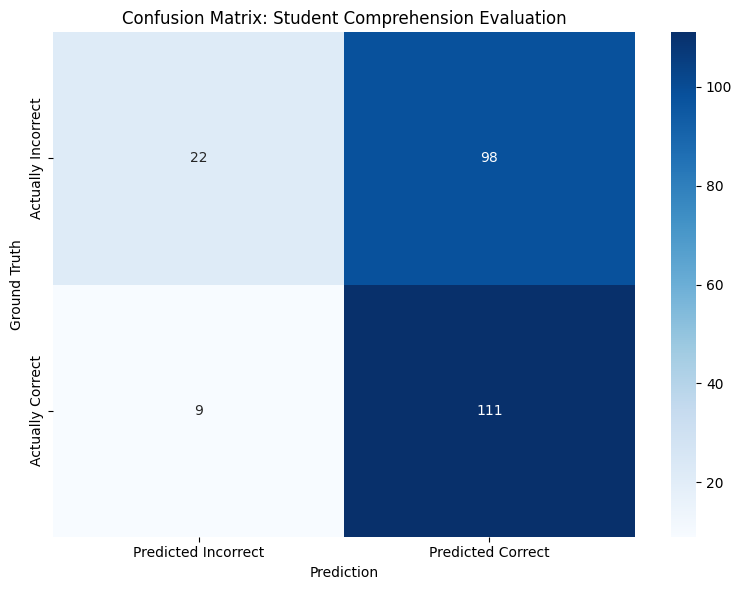

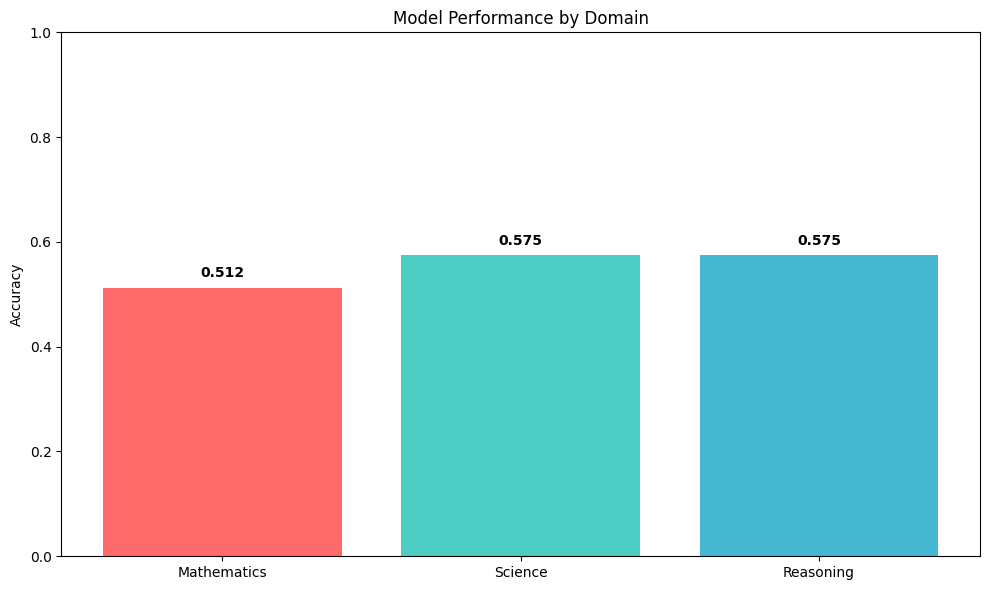

Visualizations saved to Google Drive!


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Incorrect', 'Predicted Correct'],
            yticklabels=['Actually Incorrect', 'Actually Correct'])
plt.title('Confusion Matrix: Student Comprehension Evaluation')
plt.ylabel('Ground Truth')
plt.xlabel('Prediction')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/mmlu_confusion_matrix.png', dpi=300)
plt.show()

# Accuracy by domain
domain_accs = []
domain_names = []
for domain in ['Mathematics', 'Science', 'Reasoning']:
    domain_results = results_df[results_df['domain'] == domain]
    if len(domain_results) > 0:
        acc = accuracy_score(domain_results['ground_truth'], domain_results['prediction'])
        domain_accs.append(acc)
        domain_names.append(domain)

plt.figure(figsize=(10, 6))
plt.bar(domain_names, domain_accs, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.ylabel('Accuracy')
plt.title('Model Performance by Domain')
plt.ylim([0, 1])
for i, acc in enumerate(domain_accs):
    plt.text(i, acc + 0.02, f'{acc:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/mmlu_domain_performance.png', dpi=300)
plt.show()

print("Visualizations saved to Google Drive!")